## Data Visualization & Visual Study

### Objectives
* Determine average image dimensions across the cherry leaf dataset.
* Calculate and display the **Average Image** and **Variability (Standard Deviation)** for healthy and powdery mildew leaves.
* Compute and visualize the **Visual Difference** between average healthy and average infected leaves.
* Build an **Image Montage** generator function to visually display random samples of healthy and infected leaves side by side.
* Save generated arrays and visualization plots to `outputs/v1/` for integration into the Streamlit dashboard.

### Inputs
* Cleaned and split train dataset in `inputs/cherry_leaves/train/`

### Outputs
* `outputs/v1/mean_healthy.npy`, `outputs/v1/std_healthy.npy`
* `outputs/v1/mean_powdery_mildew.npy`, `outputs/v1/std_powdery_mildew.npy`
* `outputs/v1/avg_var_healthy.png`, `outputs/v1/avg_var_powdery_mildew.png`
* `outputs/v1/avg_diff.png`

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Set project root (moves up one level if running inside jupyter_notebooks)
CURRENT_DIR = os.getcwd()
PROJECT_DIR = os.path.dirname(CURRENT_DIR) if os.path.basename(CURRENT_DIR) == 'jupyter_notebooks' else CURRENT_DIR

# Set directory paths matching your actual file tree
INPUTS_DIR = os.path.join(PROJECT_DIR, 'inputs')
SPLIT_DATA_DIR = os.path.join(INPUTS_DIR, 'cherry_leaves')
OUTPUTS_DIR = os.path.join(PROJECT_DIR, 'outputs', 'v1')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# Set dataset paths
TRAIN_DIR = os.path.join(SPLIT_DATA_DIR, 'train')
VAL_DIR = os.path.join(SPLIT_DATA_DIR, 'validation')
TEST_DIR = os.path.join(SPLIT_DATA_DIR, 'test')

if os.path.exists(TRAIN_DIR):
    LABELS = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
    print(f"Project Root: {PROJECT_DIR}")
    print(f"Loaded classes: {LABELS}")
else:
    print(f"Error: Directory not found at {TRAIN_DIR}")

Project Root: d:\books\code\code-institut\PROJECTS\cherry tree leaves
Loaded classes: ['healthy', 'powdery_mildew']


In [34]:
# Extract image width and height distributions across train split
dim_x, dim_y = [], []
valid_exts = ('.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG')

for label in LABELS:
    label_path = os.path.join(TRAIN_DIR, label)
    for img_name in os.listdir(label_path):
        if img_name.endswith(valid_exts):
            img = Image.open(os.path.join(label_path, img_name))
            w, h = img.size
            dim_x.append(w)
            dim_y.append(h)

# Plot dimension distribution histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(dim_x, kde=True, ax=axes[0], color='skyblue', bins=20)
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (pixels)')

sns.histplot(dim_y, kde=True, ax=axes[1], color='salmon', bins=20)
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (pixels)')

plt.tight_layout()
dim_plot_path = os.path.join(OUTPUTS_DIR, 'image_dimensions.png')
plt.savefig(dim_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {dim_plot_path}")
print(f"Average Image Dimensions: {int(np.mean(dim_x))}x{int(np.mean(dim_y))} px")

<Figure size 1200x400 with 2 Axes>

Saved: d:\books\code\code-institut\PROJECTS\cherry tree leaves\outputs\v1\image_dimensions.png
Average Image Dimensions: 256x256 px


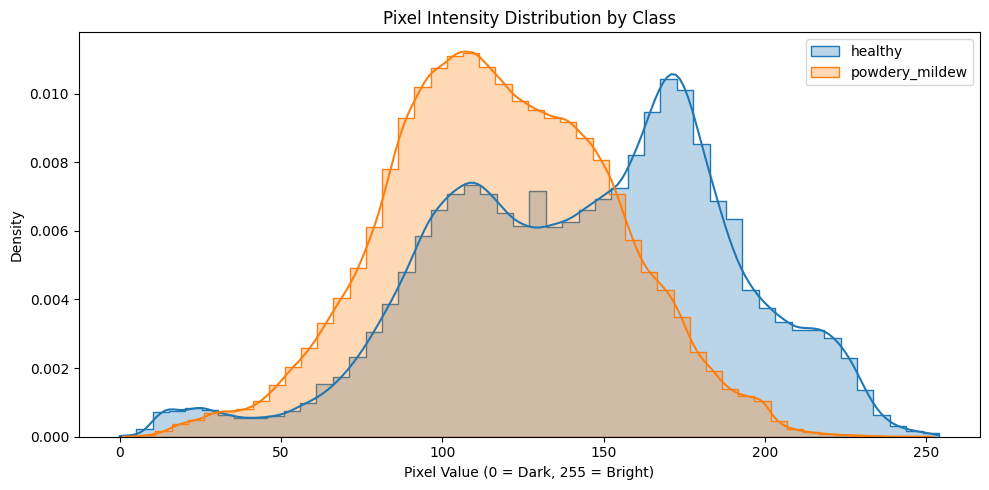

Saved: d:\books\code\code-institut\PROJECTS\cherry tree leaves\outputs\v1\pixel_intensity_histogram.png


In [35]:
import random

plt.figure(figsize=(10, 5))

for label in LABELS:
    label_path = os.path.join(TRAIN_DIR, label)
    all_files = [f for f in os.listdir(label_path) if f.endswith(valid_exts)]
    sample_files = random.sample(all_files, min(50, len(all_files)))
    pixel_vals = []
    
    for fname in sample_files:
        img = Image.open(os.path.join(label_path, fname)).convert('L')
        pixel_vals.extend(np.array(img).flatten())
            
    sns.histplot(pixel_vals, label=label, kde=True, stat="density", element="step", alpha=0.3, bins=50)

plt.title('Pixel Intensity Distribution by Class')
plt.xlabel('Pixel Value (0 = Dark, 255 = Bright)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()

pixel_plot_path = os.path.join(OUTPUTS_DIR, 'pixel_intensity_histogram.png')
plt.savefig(pixel_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {pixel_plot_path}")